# **Installs and Imports**

In [25]:
pip install -q seaborn pyDOE2 pandas numpy scikit-learn matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.optimize import differential_evolution
from scipy.stats import norm, qmc
from scipy.spatial.distance import pdist, squareform
from sklearn.model_selection import cross_val_score, LeaveOneOut, KFold
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# **Configurations**

In [27]:
FACTOR_ORDER = ["Temp", "Time", "VOacac", "DDT", "OAm"]
BOUNDS = {
    "Temp":   (260, 310),
    "Time":   (8, 90),
    "VOacac": (0.08, 0.66),
    "DDT":    (1, 5),
    "OAm":    (1, 7),
}

# **Utility Functions**

In [28]:
def extract_lengthscales_robust(kernel):
    """Robustly extract RBF lengthscales from any sklearn kernel"""
    if hasattr(kernel, 'length_scale'):
        return np.atleast_1d(kernel.length_scale)

    params = kernel.get_params()
    for key, value in params.items():
        if 'length_scale' in key and value is not None:
            return np.atleast_1d(value)

    if hasattr(kernel, 'k1'):
        ls = extract_lengthscales_robust(kernel.k1)
        if ls is not None:
            return ls

    if hasattr(kernel, 'k2'):
        ls = extract_lengthscales_robust(kernel.k2)
        if ls is not None:
            return ls

    return None


def compute_adaptive_beta(iteration, n_dimensions, delta=0.1):
    """Adaptive exploration parameter (Srinivas et al. 2010)"""
    t = max(iteration, 1)
    d = n_dimensions
    argument = t * (np.pi ** 2) * d / (6 * delta)
    beta = np.sqrt(2 * np.log(argument))
    return np.clip(beta, 1.0, 3.0)


def compute_pareto_frontier(objectives, minimize_mask):
    """Find Pareto-efficient points"""
    n_points = objectives.shape[0]
    is_pareto = np.ones(n_points, dtype=bool)

    obj_min = objectives.copy()
    for i, minimize in enumerate(minimize_mask):
        if not minimize:
            obj_min[:, i] = -obj_min[:, i]

    for i in range(n_points):
        if is_pareto[i]:
            dominates = np.all(obj_min[is_pareto] <= obj_min[i], axis=1)
            strictly_better = np.any(obj_min[is_pareto] < obj_min[i], axis=1)
            if np.any(dominates & strictly_better):
                is_pareto[i] = False

    return is_pareto


class SynthesisConstraints:
    """Physical constraints for synthesis"""

    def __init__(self):
        self.constraints = []
        self.constraint_names = []

    def add_constraint(self, name, constraint_fn):
        self.constraint_names.append(name)
        self.constraints.append(constraint_fn)

    def is_feasible(self, conditions):
        if isinstance(conditions, np.ndarray):
            conditions = {f: conditions[i] for i, f in enumerate(FACTOR_ORDER)}

        for constraint_fn in self.constraints:
            if not constraint_fn(conditions):
                return False
        return True

    def get_default_constraints(self):
        # Add common synthesis constraints
        self.add_constraint("Product Formation",
                           lambda c: not (c['Temp'] < 260 and c['Temp'] > 310))
        """self.add_constraint("Reaction Time Constraint",
                           lambda c: not (c['Time'] > 90 and c['Time'] < 8))
        self.add_constraint("Reasonable V:ligand ratio",
                           lambda c: not (c['VOacac'] > 0.6 and (c['DDT'] < 2 or c['OAm'] < 3)))"""

        print("✓ Default synthesis constraints loaded:")
        for name in self.constraint_names:
            print(f"  - {name}")
 # ============================================
# Optimization History (Diagnostics)
# ============================================
class OptimizationHistory:
    def __init__(self):
        self.iteration = []
        self.x_selected = []
        self.acquisition = []
        self.mu = []
        self.sigma = []
        self.feasibility = []
        self.objective = []

    def log(self, i, x, acq, mu, sigma, feas, obj=None):
        self.iteration.append(i)
        self.x_selected.append(x)
        self.acquisition.append(acq)
        self.mu.append(mu)
        self.sigma.append(sigma)
        self.feasibility.append(feas)
        self.objective.append(obj)

# **Gaussian Process Models**

In [29]:
class RobustMultiObjectiveBO:
    """Base BO system with GP models"""

    def __init__(self, df, target_size=None, target_polymorph=None, constraints=None):
        self.df = df
        self.target_size = target_size
        self.target_polymorph = target_polymorph
        self.factor_order = FACTOR_ORDER
        self.constraints = constraints or SynthesisConstraints()
        self.iteration = 0

        print(f"Initializing BO with {len(df)} experiments")
        self._validate_data()
        self._prepare_data()
        self._train_models()
        self._analyze_lengthscales()
        self._estimate_objective_ranges()
        self._compute_pareto_frontier()
        self.print_detailed_response_summary()

    def _validate_data(self):
        """Check data quality"""
        required_cols = self.factor_order + ['Size', 'GSD', 'Squareness', 'HasProduct', 'PhasePure']
        missing = [col for col in required_cols if col not in self.df.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        if 'Polymorph' in self.df.columns and self.target_polymorph:
            target_count = (self.df['Polymorph'] == self.target_polymorph).sum()
            print(f"  Target polymorph '{self.target_polymorph}': {target_count} samples")

    def _prepare_data(self):
        """Prepare training data"""
        regression_filter = (
            (self.df['HasProduct'] == 1) &
            self.df['Size'].notna() &
            self.df['GSD'].notna() &
            self.df['Squareness'].notna()
        )

        self.regression_data = self.df[regression_filter].copy()
        self.classification_data = self.df.copy()

        print(f"Training: {len(self.regression_data)} regression, {len(self.classification_data)} classification")

        X_reg = self.regression_data[self.factor_order].values
        self.X_scaler = StandardScaler().fit(X_reg)

        self.response_scalers = {}
        for response in ['Size', 'GSD', 'Squareness']:
            y = self.regression_data[response].values.reshape(-1, 1)
            self.response_scalers[response] = StandardScaler().fit(y)

    def _train_models(self):
        """
        Train all GP models with CORRECTED normalization and ISOTROPIC kernels.
        """

        # Define kernels - CHANGED TO ISOTROPIC (scalar length_scale)
        # This prevents overfitting on small datasets
        kernels = [
            # Kernel 1: Standard Isotropic RBF
            C(1.0, (0.1, 100.0)) * RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(0.01, (1e-4, 0.5)),

            # Kernel 2: Matern Kernel (Isotropic)
            C(1.0, (0.1, 100.0)) * Matern(length_scale=1.0, length_scale_bounds=(0.1, 10.0), nu=2.5) + WhiteKernel(0.01, (1e-4, 0.5)),

            # Kernel 3: RBF with wider bounds
            C(1.0, (0.1, 100.0)) * RBF(length_scale=2.0, length_scale_bounds=(0.5, 20.0)) + WhiteKernel(0.05, (1e-4, 0.5)),
        ]

        def gp_cv_r2_corrected(kernel, X, y, n_splits=5):
            """
            Compute CV R² Mean and Std.
            """
            n = len(X)
            n_splits = min(n_splits, max(2, n // 3))

            if n < 6:
                return -np.inf, 0.0

            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            scores = []

            for train_idx, test_idx in kf.split(X):
                try:
                    gp = GaussianProcessRegressor(
                        kernel=kernel.clone_with_theta(kernel.theta),
                        n_restarts_optimizer=5, # Increased restarts
                        alpha=1e-6,
                        normalize_y=True,
                        random_state=42
                    )

                    # Fit and Predict
                    gp.fit(X[train_idx], y[train_idx])
                    y_pred = gp.predict(X[test_idx])

                    # Compute R2 for this fold
                    score = r2_score(y[test_idx], y_pred)
                    scores.append(score)

                except Exception as e:
                    continue

            if len(scores) == 0:
                return -np.inf, 0.0

            return np.mean(scores), np.std(scores)

        print("\n" + "="*70)
        print("TRAINING GP MODELS (CORRECTED)")
        print("="*70)

        X_train = self.X_scaler.transform(
            self.regression_data[self.factor_order].values
        )

        self.models = {}
        self.cv_scores = {}

        for response in ["Size", "GSD", "Squareness"]:
            print(f"\nTraining {response} model:")

            y_train = self.regression_data[response].values
            print(f"  Data: n={len(y_train)}, mean={np.mean(y_train):.3f}, std={np.std(y_train):.3f}")

            best_score = -np.inf
            best_std = 0.0
            best_model = None
            best_kernel_name = ""

            for i, kernel in enumerate(kernels):
                try:
                    # Returns (mean, std)
                    cv_mean, cv_std = gp_cv_r2_corrected(kernel, X_train, y_train, n_splits=5)

                    print(f"  Kernel {i+1}: CV R² = {cv_mean:.4f} ± {cv_std:.4f}")

                    if cv_mean > best_score:
                        best_score = cv_mean
                        best_std = cv_std
                        best_kernel_name = f"Kernel_{i+1}"

                        best_model = GaussianProcessRegressor(
                            kernel=kernel,
                            n_restarts_optimizer=10,
                            alpha=1e-6,
                            normalize_y=True,
                            random_state=42
                        )
                        best_model.fit(X_train, y_train)

                except Exception as e:
                    print(f"  Kernel {i+1} failed: {e}")
                    continue

            if best_model is None:
                print(f"  WARNING: All kernels failed, using fallback")
                fallback_kernel = C(1.0) * RBF(1.0)
                best_model = GaussianProcessRegressor(
                    kernel=fallback_kernel,
                    alpha=1e-3,
                    normalize_y=True,
                    random_state=42
                )
                best_model.fit(X_train, y_train)
                best_score = -1.0 # arbitrary low score

            self.models[response] = best_model
            self.cv_scores[response] = (best_score, best_std)

            print(f"  ✓ Best: {best_kernel_name}, CV R² = {best_score:.4f}")

        # Train classification models (unchanged)
        print("\nTraining classification models:")
        X_class = self.X_scaler.transform(self.classification_data[self.factor_order].values)
        kernel_class = C(1.0) * RBF(1.0)

        y_product = self.classification_data['HasProduct'].values
        self.product_model = GaussianProcessClassifier(
            kernel=kernel_class, random_state=42, n_restarts_optimizer=3
        )
        self.product_model.fit(X_class, y_product)
        print("  ✓ Product formation model")

        product_mask = self.classification_data['HasProduct'] == 1
        X_purity = X_class[product_mask]
        y_purity = self.classification_data.loc[product_mask, 'PhasePure'].values
        self.purity_model = GaussianProcessClassifier(
            kernel=kernel_class, random_state=42, n_restarts_optimizer=3
        )
        self.purity_model.fit(X_purity, y_purity)
        print("  ✓ Phase purity model")

        # Polymorph model
        if 'Polymorph' in self.df.columns:
            poly_mask = (self.classification_data['HasProduct'] == 1) & self.classification_data['Polymorph'].notna()
            X_poly = X_class[poly_mask]
            y_poly = self.classification_data.loc[poly_mask, 'Polymorph'].values

            if len(np.unique(y_poly)) > 1:
                self.polymorph_encoder = LabelEncoder()
                y_poly_encoded = self.polymorph_encoder.fit_transform(y_poly)
                self.polymorph_classes = self.polymorph_encoder.classes_
                self.models['Polymorph'] = GaussianProcessClassifier(
                    kernel=kernel_class, random_state=42, n_restarts_optimizer=3
                )
                self.models['Polymorph'].fit(X_poly, y_poly_encoded)
                print("  ✓ Polymorph model")
            else:
                self.models['Polymorph'] = None
                print("  ⚠ Polymorph model: insufficient classes")
        else:
            self.models['Polymorph'] = None

    def _analyze_lengthscales(self):
        """Analyze factor importance from lengthscales"""
        print("\n" + "="*70)
        print("LENGTHSCALE ANALYSIS (Factor Importance)")
        print("="*70)

        # Note: Since we switched to Isotropic kernels, lengthscale analysis
        # is less detailed (one scale per model), but we can still show it.
        self.lengthscales = {}
        for response in ['Size', 'GSD', 'Squareness']:
            ls = extract_lengthscales_robust(self.models[response].kernel_)

            if ls is not None:
                self.lengthscales[response] = ls
                print(f"\n{response}:")
                # Handle scalar lengthscales
                if np.size(ls) == 1:
                     print(f"  Isotropic Lengthscale: {ls[0]:.3f}")
                else:
                    importance = 1.0 / ls
                    importance_normalized = importance / np.sum(importance)
                    for factor, length, imp in sorted(zip(self.factor_order, ls, importance_normalized),
                                                     key=lambda x: x[2], reverse=True):
                        print(f"  {factor:8s}: ℓ={length:6.3f}  →  Importance={imp:5.1%}")

    def _estimate_objective_ranges(self):
        """Estimate ideal and nadir points"""
        data = self.regression_data
        self.ideal_gsd = data['GSD'].min()
        self.nadir_gsd = data['GSD'].max()
        self.ideal_sq = data['Squareness'].max()
        self.nadir_sq = data['Squareness'].min()

    def _compute_pareto_frontier(self):
        """Compute Pareto frontier"""
        objectives = np.column_stack([self.regression_data['GSD'].values,
                                     self.regression_data['Squareness'].values])
        self.pareto_mask = compute_pareto_frontier(objectives, [True, False])
        self.pareto_data = self.regression_data[self.pareto_mask].copy()
        print(f"\nPareto frontier: {self.pareto_mask.sum()} / {len(self.regression_data)} points")

    def print_detailed_response_summary(self):
        """Print comprehensive response variable statistics"""
        print("\n" + "="*70)
        print("DETAILED RESPONSE VARIABLE SUMMARY")
        print("="*70)

        data = self.regression_data

        for response in ['Size', 'GSD', 'Squareness']:
            values = data[response].values

            print(f"\n{response}:")
            print(f"  Count:        {len(values)}")
            print(f"  Min:          {values.min():.4f}")
            print(f"  25th %ile:    {np.percentile(values, 25):.4f}")
            print(f"  Median:       {np.median(values):.4f}")
            print(f"  Mean:         {values.mean():.4f}")
            print(f"  75th %ile:    {np.percentile(values, 75):.4f}")
            print(f"  Max:          {values.max():.4f}")
            print(f"  Std Dev:      {values.std():.4f}")
            print(f"  Range:        {values.max() - values.min():.4f}")
            print(f"  CV:           {(values.std() / values.mean()) * 100:.1f}%")

            # Show ideal vs nadir
            if response == 'GSD':
                print(f"  → Ideal (min): {self.ideal_gsd:.4f}")
                print(f"  → Nadir (max): {self.nadir_gsd:.4f}")
            elif response == 'Squareness':
                print(f"  → Ideal (max): {self.ideal_sq:.4f}")
                print(f"  → Nadir (min): {self.nadir_sq:.4f}")

            # CV score for context
            cv_r2, cv_std = self.cv_scores[response]
            print(f"  → Model CV R²: {cv_r2:.3f} ± {cv_std:.3f}")

        print("\n" + "="*70)

    def predict(self, X):
        """Make predictions with CORRECTED scaling."""
        X_scaled = self.X_scaler.transform(X)
        predictions = {}

        for response in ['Size', 'GSD', 'Squareness']:
            y_mean, y_std = self.models[response].predict(X_scaled, return_std=True)
            # Predictions are ALREADY in original scale!
            predictions[response] = {'mean': y_mean, 'std': y_std}

        predictions['P_product'] = self.product_model.predict_proba(X_scaled)[:, 1]
        predictions['P_pure'] = self.purity_model.predict_proba(X_scaled)[:, 1]

        if self.models.get('Polymorph'):
            poly_probs = self.models['Polymorph'].predict_proba(X_scaled)
            for i, poly_class in enumerate(self.polymorph_classes):
                predictions[f'P_{poly_class}'] = poly_probs[:, i]

        return predictions

# **Statistical Weights**

In [30]:
class StatisticalWeights:
    """Calculate data-driven weights"""

    def __init__(self, bo_system, importance_weights=None):
        self.bo = bo_system

        print("\n" + "="*70)
        print("CALCULATING STATISTICAL WEIGHTS")
        print("="*70)

        # Variability-based weights
        data = self.bo.regression_data
        self.w_gsd_quality = np.std(data['GSD']) / np.mean(data['GSD'])
        self.w_sq_quality = np.std(data['Squareness']) / np.mean(data['Squareness'])
        self.w_size = np.std(data['Size']) / np.mean(data['Size'])

        print(f"GSD CV: {self.w_gsd_quality:.3f}")
        print(f"Squareness CV: {self.w_sq_quality:.3f}")
        print(f"Size CV: {self.w_size:.3f}")

        # Success-based weights
        all_data = self.bo.classification_data
        product_rate = all_data['HasProduct'].mean()
        self.w_product = 1.0 - product_rate

        product_data = all_data[all_data['HasProduct'] == 1]
        purity_rate = product_data['PhasePure'].mean() if len(product_data) > 0 else 0.5
        self.w_purity = 1.0 - purity_rate

        # Apply importance and normalize
        if importance_weights is None:
            importance_weights = {'quality': 1.0, 'size': 1.0, 'success': 1.0, 'polymorph': 1.0}

        total = sum(importance_weights.values())
        self.importance = {k: v/total for k, v in importance_weights.items()}

        self.final_w_gsd = self.w_gsd_quality * self.importance['quality']
        self.final_w_sq = self.w_sq_quality * self.importance['quality']
        self.final_w_size = self.w_size * self.importance['size']
        self.final_w_success = (self.w_product + self.w_purity) / 2 * self.importance['success']
        self.final_w_polymorph = 0.5 * self.importance['polymorph']

        # Normalize
        total_final = (self.final_w_gsd + self.final_w_sq + self.final_w_size +
                      self.final_w_success + self.final_w_polymorph)

        self.final_w_gsd /= total_final
        self.final_w_sq /= total_final
        self.final_w_size /= total_final
        self.final_w_success /= total_final
        self.final_w_polymorph /= total_final

        print(f"\nFINAL WEIGHTS: GSD={self.final_w_gsd:.3f}, Sq={self.final_w_sq:.3f}, "
              f"Size={self.final_w_size:.3f}, Success={self.final_w_success:.3f}")

# **Acquisition Functions (EI, UCB/LCB)**

In [31]:
class AcquisitionFunction:
    """Base class for acquisition functions"""

    def __init__(self, bo_system, weights):
        self.bo = bo_system
        self.weights = weights

    def __call__(self, x):
        return self.evaluate(x)

    def evaluate(self, x):
        raise NotImplementedError


class WeightedUCBLCB(AcquisitionFunction):
    """Weighted UCB/LCB with adaptive beta"""

    def evaluate(self, x):
        X = x.reshape(1, -1)
        preds = self.bo.predict(X)

        beta = compute_adaptive_beta(self.bo.iteration, len(self.bo.factor_order))
        score = 0.0

        # GSD (minimize with UCB)
        gsd_ucb = preds['GSD']['mean'][0] + beta * preds['GSD']['std'][0]
        gsd_norm = (gsd_ucb - self.bo.ideal_gsd) / max(self.bo.nadir_gsd - self.bo.ideal_gsd, 0.1)
        score += self.weights.final_w_gsd * max(0, gsd_norm)

        # Squareness (maximize with LCB)
        sq_lcb = preds['Squareness']['mean'][0] - beta * preds['Squareness']['std'][0]
        sq_norm = (self.bo.ideal_sq - sq_lcb) / max(self.bo.ideal_sq - self.bo.nadir_sq, 0.1)
        score += self.weights.final_w_sq * max(0, sq_norm)

        # Size target
        if self.bo.target_size is not None:
            size_error = abs(preds['Size']['mean'][0] - self.bo.target_size) / self.bo.target_size
            score += self.weights.final_w_size * size_error

        # Success probability
        p_success = preds['P_product'][0] * preds['P_pure'][0]
        score += self.weights.final_w_success * (1.0 - p_success)

        # Polymorph
        if self.bo.target_polymorph and self.bo.models.get('Polymorph'):
            p_key = f'P_{self.bo.target_polymorph}'
            if p_key in preds:
                score += self.weights.final_w_polymorph * (1.0 - preds[p_key][0])

        return score


class ExpectedImprovement(AcquisitionFunction):
    """Expected Improvement (Jones et al. 1998)"""

    def __init__(self, bo_system, weights):
        super().__init__(bo_system, weights)
        self.current_best = self._compute_current_best()

    def _compute_current_best(self):
        """Find best scalarized objective from training data"""
        train_scores = []
        for idx in range(len(self.bo.regression_data)):
            row = self.bo.regression_data.iloc[idx]

            # GSD contribution
            gsd_norm = (row['GSD'] - self.bo.ideal_gsd) / max(self.bo.nadir_gsd - self.bo.ideal_gsd, 0.1)

            # Squareness contribution
            sq_norm = (self.bo.ideal_sq - row['Squareness']) / max(self.bo.ideal_sq - self.bo.nadir_sq, 0.1)

            # Size contribution
            size_error = 0.0
            if self.bo.target_size is not None:
                size_error = abs(row['Size'] - self.bo.target_size) / self.bo.target_size

            score = (self.weights.final_w_gsd * gsd_norm +
                    self.weights.final_w_sq * sq_norm +
                    self.weights.final_w_size * size_error)

            train_scores.append(score)

        return min(train_scores)

    def evaluate(self, x):
        X = x.reshape(1, -1)
        preds = self.bo.predict(X)

        # Scalarized objective (mean)
        gsd_norm = (preds['GSD']['mean'][0] - self.bo.ideal_gsd) / max(self.bo.nadir_gsd - self.bo.ideal_gsd, 0.1)
        sq_norm = (self.bo.ideal_sq - preds['Squareness']['mean'][0]) / max(self.bo.ideal_sq - self.bo.nadir_sq, 0.1)

        # Size contribution
        size_error = 0.0
        size_std = 0.0
        if self.bo.target_size is not None:
            size_mean = preds['Size']['mean'][0]
            size_std = preds['Size']['std'][0]
            size_error = abs(size_mean - self.bo.target_size) / self.bo.target_size

        score = (self.weights.final_w_gsd * gsd_norm +
                self.weights.final_w_sq * sq_norm +
                self.weights.final_w_size * size_error)

        # Combined uncertainty (include size)
        combined_std = np.sqrt(
            (self.weights.final_w_gsd * preds['GSD']['std'][0])**2 +
            (self.weights.final_w_sq * preds['Squareness']['std'][0])**2 +
            (self.weights.final_w_size * size_std)**2
        )

        # EI calculation
        if combined_std > 1e-6:
            z = (self.current_best - score) / combined_std
            ei = (self.current_best - score) * norm.cdf(z) + combined_std * norm.pdf(z)
        else:
            ei = 0.0

        return -ei

# **Multi-Objective BO Optimizer**

In [32]:
class MultiObjectiveBO:
    """Main BO optimizer with multiple acquisition functions"""

    def __init__(self, bo_system, importance_weights=None):
        self.bo = bo_system
        self.weights = StatisticalWeights(bo_system, importance_weights)

        # Register acquisition functions
        self.acquisition_functions = {
            'weighted_ucb_lcb': WeightedUCBLCB(bo_system, self.weights),
            'expected_improvement': ExpectedImprovement(bo_system, self.weights)
        }

    def optimize(self, target_size=None, target_polymorph=None, n_candidates=3,
                 acquisition='weighted_ucb_lcb', n_restarts=50, history=None):
        """
        Generate recommendations using TRADITIONAL Bayesian optimization

        This version:
        1. Runs multi-start optimization on the acquisition function
        2. Returns the N best candidates by acquisition value
        3. No forced spatial diversity - let the acquisition function handle exploration

        Parameters:
        -----------
        target_size : float, optional
            Target particle size (nm)
        target_polymorph : str, optional
            Target polymorph (e.g., 'cubic')
        n_candidates : int
            Number of recommendations
        acquisition : str
            'weighted_ucb_lcb' or 'expected_improvement'
        n_restarts : int
            Number of random restarts for optimization (default: 50)
            Higher = more thorough search, slower
        """
        if target_size is not None:
            self.bo.target_size = target_size
        if target_polymorph is not None:
            self.bo.target_polymorph = target_polymorph

        self.bo.iteration += 1

        # Select acquisition function
        if acquisition not in self.acquisition_functions:
            raise ValueError(f"Unknown acquisition: {acquisition}")

        acq_fn = self.acquisition_functions[acquisition]
        print(f"\nUsing {acquisition.upper().replace('_', ' ')}")

        if acquisition == 'weighted_ucb_lcb':
            beta = compute_adaptive_beta(self.bo.iteration, len(self.bo.factor_order))
            print(f"  Iteration {self.bo.iteration}, adaptive β = {beta:.3f}")

        def constrained_acq(x):
            """Acquisition with constraints"""
            if not self.bo.constraints.is_feasible(x):
                return 1e10
            return acq_fn(x)

        bounds = [(BOUNDS[f][0], BOUNDS[f][1]) for f in self.bo.factor_order]

        print(f"\nOptimizing acquisition function with {n_restarts} random restarts...")

        # Multi-start optimization of acquisition function
        all_results = []

        for i in range(n_restarts):
            # Random initialization
            seed = np.random.randint(0, 100000)

            result = differential_evolution(
                constrained_acq,
                bounds,
                seed=int(seed),
                maxiter=300,      # More iterations for thorough optimization
                popsize=30,       # Larger population
                workers=1,
                atol=1e-4,        # Tighter tolerance
                tol=1e-4
            )

            all_results.append({
                'x': result.x,
                'score': result.fun,
                'success': result.success
            })

            # Progress indicator
            if (i + 1) % 10 == 0:
                print(f"  Completed {i + 1}/{n_restarts} restarts...")

        # Sort by acquisition value (lower = better since we're minimizing)
        all_results.sort(key=lambda r: r['score'])

        # Take top N candidates by acquisition value
        # Optional: Remove near-duplicates (points very close in parameter space)
        final_candidates = []
        selected_indices = []
        min_distance = 0.05  # Minimum normalized distance between candidates

        for idx, res in enumerate(all_results):
            # Check if this candidate is too close to any already selected
            x_norm = np.array([
                (res['x'][j] - bounds[j][0]) / (bounds[j][1] - bounds[j][0])
                for j in range(len(bounds))
            ])

            too_close = False
            for prev in final_candidates:
                prev_norm = np.array([
                    (prev['x'][j] - bounds[j][0]) / (bounds[j][1] - bounds[j][0])
                    for j in range(len(bounds))
                ])
                distance = np.linalg.norm(x_norm - prev_norm)

                if distance < min_distance:
                    too_close = True
                    break

            if not too_close:
                final_candidates.append(res)

            if len(final_candidates) >= n_candidates:
                break

        # If we didn't get enough candidates (unlikely), take from all_results
        if len(final_candidates) < n_candidates:
            print(f"  Warning: Only found {len(final_candidates)} sufficiently distinct candidates")
            print(f"  Adding {n_candidates - len(final_candidates)} more from best remaining...")
            for idx, res in enumerate(all_results):
                if idx not in selected_indices:
                    final_candidates.append(res)
                    selected_indices.append(idx)
                if len(final_candidates) >= n_candidates:
                    break

        print(f"  Selected {len(final_candidates)} candidates")
        print(f"  Acquisition scores: {[f'{c['score']:.4f}' for c in final_candidates]}")

        # Convert to DataFrame with predictions
        recommendations = []
        for rec_idx, res in enumerate(final_candidates):

            rec = {f: res['x'][j] for j, f in enumerate(self.bo.factor_order)}
            rec['Acquisition_Score'] = res['score']

            # Get predictions
            preds = self.bo.predict(res['x'].reshape(1, -1))

            # Diagnostics logging
            if history is not None:
                history.log(
                    i=rec_idx,
                    x=res['x'],
                    acq=res['score'],
                    mu=float(preds['Size']['mean'][0]),
                    sigma=float(preds['Size']['std'][0]),
                    feas=float(preds['P_product'][0] * preds['P_pure'][0]),
                    obj=float(res['score'])
                )

            rec['Pred_Size'] = preds['Size']['mean'][0]
            rec['Pred_Size_Std'] = preds['Size']['std'][0]
            rec['Pred_GSD'] = preds['GSD']['mean'][0]
            rec['Pred_GSD_Std'] = preds['GSD']['std'][0]
            rec['Pred_Squareness'] = preds['Squareness']['mean'][0]
            rec['Pred_Squareness_Std'] = preds['Squareness']['std'][0]
            rec['P_Success'] = preds['P_product'][0] * preds['P_pure'][0]

            if self.bo.models.get('Polymorph'):
                for poly_class in self.bo.polymorph_classes:
                    rec[f'P_{poly_class}'] = preds[f'P_{poly_class}'][0]

            recommendations.append(rec)

        if history is not None:
            history.kernel_size = str(self.bo.models['Size'].kernel_)
            history.kernel_gsd = str(self.bo.models['GSD'].kernel_)
            history.kernel_squareness = str(self.bo.models['Squareness'].kernel_)

        return pd.DataFrame(recommendations)


# **Visualization Module**

In [33]:
class BOVisualizer:
    """Complete visualization suite for BO analysis"""

    def __init__(self, bo_optimizer):
        self.bo = bo_optimizer.bo
        self.weights = bo_optimizer.weights
        self.optimizer = bo_optimizer

    def plot_all(self, recommendations=None):
        """Generate all standard visualizations"""
        print("\nGenerating visualizations...")

        self.plot_model_quality()
        self.plot_lengthscales()
        self.plot_gp_predictions()
        self.plot_acquisition_surface()
        self.plot_uncertainty_map()
        self.plot_pareto_frontier()

        if recommendations is not None:
            self.plot_parallel_coordinates(recommendations)

        plt.show()

    # ========== CORE DIAGNOSTIC PLOTS ==========

    def plot_model_quality(self, figsize=(15, 5)):
        """Predicted vs Actual with CV scores"""
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle('Model Quality: Predicted vs Actual', fontsize=14, fontweight='bold')

        X = self.bo.regression_data[self.bo.factor_order].values
        preds = self.bo.predict(X)

        for idx, resp in enumerate(['Size', 'GSD', 'Squareness']):
            ax = axes[idx]

            actual = self.bo.regression_data[resp].values
            predicted = preds[resp]['mean']

            # Perfect prediction line
            min_val = min(actual.min(), predicted.min())
            max_val = max(actual.max(), predicted.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, lw=2)

            # Scatter
            ax.scatter(actual, predicted, alpha=0.7, s=120, edgecolor='black', lw=1.5)

            # R² scores
            train_r2 = r2_score(actual, predicted)
            cv_r2, cv_std = self.bo.cv_scores[resp]

            ax.set_xlabel(f'Actual {resp}', fontsize=11, fontweight='bold')
            ax.set_ylabel(f'Predicted {resp}', fontsize=11, fontweight='bold')
            ax.set_title(f'{resp}\nTrain R²={train_r2:.3f}, CV R²={cv_r2:.3f}±{cv_std:.3f}',
                        fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_lengthscales(self, figsize=(16, 5)):
        """Factor importance from lengthscales + CV scores"""
        fig, axes = plt.subplots(1, 4, figsize=figsize)
        fig.suptitle('Factor Importance + Model Quality', fontsize=14, fontweight='bold')

        responses = ['Size', 'GSD', 'Squareness']
        colors = ['#2E86AB', '#A23B72', '#F18F01']

        for idx, resp in enumerate(responses):
            ax = axes[idx]

            if resp not in self.bo.lengthscales:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
                ax.set_title(f'{resp}', fontsize=11, fontweight='bold')
                continue

            ls = self.bo.lengthscales[resp]
            importance = 1.0 / ls
            importance_norm = importance / importance.sum()

            ax.barh(self.bo.factor_order, importance_norm, color=colors[idx],
                   alpha=0.7, edgecolor='black', lw=1.5)

            cv_r2, cv_std = self.bo.cv_scores[resp]
            ax.set_title(f'{resp}\nCV R²={cv_r2:.3f}±{cv_std:.3f}',
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Importance', fontsize=10, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)

            # Add lengthscale values
            for i, (factor, ls_val, imp) in enumerate(zip(self.bo.factor_order, ls, importance_norm)):
                ax.text(imp + 0.01, i, f'ℓ={ls_val:.2f}', va='center', fontsize=8)

        # CV summary
        ax = axes[3]
        cv_means = [self.bo.cv_scores[r][0] for r in responses]
        cv_stds = [self.bo.cv_scores[r][1] for r in responses]

        x = np.arange(len(responses))
        ax.bar(x, cv_means, yerr=cv_stds, capsize=10, color=colors,
              alpha=0.7, edgecolor='black', lw=2)
        ax.axhline(0.75, color='red', linestyle='--', lw=2, alpha=0.7, label='Target=0.75')

        ax.set_xticks(x)
        ax.set_xticklabels(responses, fontsize=10, fontweight='bold')
        ax.set_ylabel('CV R²', fontsize=10, fontweight='bold')
        ax.set_title('Model Quality', fontsize=11, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        return fig

    # ========== GP UNCERTAINTY PLOTS ==========

    def plot_gp_predictions(self, factor='Temp', n_points=100, figsize=(15, 10)):
        """GP predictions with 95% CI"""
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'GP Predictions vs {factor} with 95% CI', fontsize=14, fontweight='bold')

        # Median conditions
        median_cond = {f: self.bo.regression_data[f].median() for f in self.bo.factor_order}
        factor_range = np.linspace(BOUNDS[factor][0], BOUNDS[factor][1], n_points)

        predictions = {resp: {'mean': [], 'lower': [], 'upper': []}
                      for resp in ['Size', 'GSD', 'Squareness']}
        p_success = []

        for val in factor_range:
            cond = median_cond.copy()
            cond[factor] = val
            x = np.array([cond[f] for f in self.bo.factor_order])
            preds = self.bo.predict(x.reshape(1, -1))

            for resp in ['Size', 'GSD', 'Squareness']:
                mean = preds[resp]['mean'][0]
                std = preds[resp]['std'][0]
                predictions[resp]['mean'].append(mean)
                predictions[resp]['lower'].append(mean - 1.96*std)
                predictions[resp]['upper'].append(mean + 1.96*std)

            p_success.append(preds['P_product'][0] * preds['P_pure'][0])

        # Plot responses
        for idx, resp in enumerate(['Size', 'GSD', 'Squareness']):
            ax = axes[idx // 2, idx % 2]

            ax.plot(factor_range, predictions[resp]['mean'], 'b-', lw=3, label='Mean')
            ax.fill_between(factor_range, predictions[resp]['lower'],
                           predictions[resp]['upper'], alpha=0.3, color='blue', label='95% CI')

            train_data = self.bo.regression_data
            ax.scatter(train_data[factor], train_data[resp], color='red', s=100,
                      marker='*', edgecolors='black', lw=1.5, label='Training', zorder=4)

            ax.set_xlabel(factor, fontsize=11, fontweight='bold')
            ax.set_ylabel(resp, fontsize=11, fontweight='bold')
            ax.set_title(f'{resp} Prediction', fontweight='bold', fontsize=12)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        # Success probability
        ax = axes[1, 1]
        ax.plot(factor_range, p_success, 'g-', lw=3)
        ax.fill_between(factor_range, 0, p_success, alpha=0.3, color='green')
        ax.set_xlabel(factor, fontsize=11, fontweight='bold')
        ax.set_ylabel('P(Success)', fontsize=11, fontweight='bold')
        ax.set_title('Success Probability', fontweight='bold', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])

        plt.tight_layout()
        return fig

    def plot_acquisition_surface(self, factor1='Temp', factor2='Time',
                                 n_points=50, figsize=(16, 6)):
        """Acquisition function landscape"""
        fig = plt.figure(figsize=figsize)

        # Get acquisition function
        acq_fn = self.optimizer.acquisition_functions['weighted_ucb_lcb']

        # Median conditions
        median_cond = {f: self.bo.regression_data[f].median() for f in self.bo.factor_order}

        # Create grid
        f1_range = np.linspace(BOUNDS[factor1][0], BOUNDS[factor1][1], n_points)
        f2_range = np.linspace(BOUNDS[factor2][0], BOUNDS[factor2][1], n_points)
        F1, F2 = np.meshgrid(f1_range, f2_range)

        Z = np.zeros_like(F1)
        for i in range(n_points):
            for j in range(n_points):
                cond = median_cond.copy()
                cond[factor1] = F1[i, j]
                cond[factor2] = F2[i, j]
                x = np.array([cond[f] for f in self.bo.factor_order])
                Z[i, j] = acq_fn(x)

        # 2D contour
        ax1 = fig.add_subplot(121)
        contour = ax1.contourf(F1, F2, Z, levels=25, cmap='plasma_r')
        plt.colorbar(contour, ax=ax1, label='Acquisition (lower=better)')

        train_data = self.bo.regression_data
        ax1.scatter(train_data[factor1], train_data[factor2], c='red', s=150,
                   marker='*', edgecolors='white', lw=2, label='Training', zorder=5)

        ax1.set_xlabel(factor1, fontsize=11, fontweight='bold')
        ax1.set_ylabel(factor2, fontsize=11, fontweight='bold')
        ax1.set_title('Acquisition Landscape', fontweight='bold', fontsize=12)
        ax1.legend(fontsize=10)

        # 3D surface
        ax2 = fig.add_subplot(122, projection='3d')
        ax2.plot_surface(F1, F2, Z, cmap='plasma_r', alpha=0.9, edgecolor='none')
        ax2.set_xlabel(factor1, fontsize=10, fontweight='bold')
        ax2.set_ylabel(factor2, fontsize=10, fontweight='bold')
        ax2.set_zlabel('Acquisition', fontsize=10, fontweight='bold')
        ax2.set_title('3D Surface', fontweight='bold', fontsize=12)
        ax2.view_init(elev=25, azim=45)

        plt.suptitle(f'Acquisition Function: {factor1} vs {factor2}',
                    fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        return fig

    def plot_uncertainty_map(self, factor1='Temp', factor2='Time', response='GSD',
                            n_points=50, figsize=(14, 6)):
        """Model uncertainty quantification"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Median conditions
        median_cond = {f: self.bo.regression_data[f].median() for f in self.bo.factor_order}

        # Create grid
        f1_range = np.linspace(BOUNDS[factor1][0], BOUNDS[factor1][1], n_points)
        f2_range = np.linspace(BOUNDS[factor2][0], BOUNDS[factor2][1], n_points)
        F1, F2 = np.meshgrid(f1_range, f2_range)

        Z_mean = np.zeros_like(F1)
        Z_std = np.zeros_like(F1)

        for i in range(n_points):
            for j in range(n_points):
                cond = median_cond.copy()
                cond[factor1] = F1[i, j]
                cond[factor2] = F2[i, j]
                x = np.array([cond[f] for f in self.bo.factor_order])
                preds = self.bo.predict(x.reshape(1, -1))
                Z_mean[i, j] = preds[response]['mean'][0]
                Z_std[i, j] = preds[response]['std'][0]

        # Mean prediction
        im1 = ax1.contourf(F1, F2, Z_mean, levels=25, cmap='RdYlGn_r')
        plt.colorbar(im1, ax=ax1, label=f'{response} Prediction')

        train_data = self.bo.regression_data
        ax1.scatter(train_data[factor1], train_data[factor2], c='blue', s=100,
                   marker='o', edgecolors='white', lw=1.5, label='Training', zorder=5)

        ax1.set_xlabel(factor1, fontsize=11, fontweight='bold')
        ax1.set_ylabel(factor2, fontsize=11, fontweight='bold')
        ax1.set_title(f'{response} Mean', fontweight='bold', fontsize=12)
        ax1.legend()

        # Uncertainty
        im2 = ax2.contourf(F1, F2, Z_std, levels=25, cmap='YlOrRd')
        plt.colorbar(im2, ax=ax2, label='Uncertainty (Std Dev)')

        ax2.scatter(train_data[factor1], train_data[factor2], c='blue', s=100,
                   marker='o', edgecolors='white', lw=1.5, label='Training', zorder=5)

        ax2.set_xlabel(factor1, fontsize=11, fontweight='bold')
        ax2.set_ylabel(factor2, fontsize=11, fontweight='bold')
        ax2.set_title('Uncertainty', fontweight='bold', fontsize=12)
        ax2.legend()

        plt.suptitle(f'{response}: Prediction & Uncertainty ({factor1} vs {factor2})',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        return fig

    # ========== MULTI-OBJECTIVE ANALYSIS ==========

    def plot_pareto_frontier(self, figsize=(14, 6)):
        """Multi-objective trade-off with Pareto frontier"""
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        data = self.bo.regression_data
        non_pareto = data[~self.bo.pareto_mask]
        pareto = data[self.bo.pareto_mask]

        # GSD vs Squareness
        ax1 = axes[0]
        scatter1 = ax1.scatter(non_pareto['GSD'], non_pareto['Squareness'],
                             c=non_pareto['Size'], s=120, alpha=0.5, cmap='viridis',
                             edgecolors='gray', lw=1, label='Non-Pareto')

        ax1.scatter(pareto['GSD'], pareto['Squareness'], c=pareto['Size'],
                   s=250, alpha=0.9, marker='*', cmap='viridis',
                   edgecolors='red', lw=3, label='Pareto', zorder=10)

        plt.colorbar(scatter1, ax=ax1, label='Size (nm)')

        ax1.set_xlabel('GSD (minimize →)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Squareness (← maximize)', fontsize=11, fontweight='bold')
        ax1.set_title(f'Pareto Frontier ({len(pareto)}/{len(data)} points)',
                     fontweight='bold', fontsize=12)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)

        # Optimization direction arrow
        ax1.annotate('', xy=(ax1.get_xlim()[0], ax1.get_ylim()[1]),
                    xytext=(ax1.get_xlim()[0] + 0.002, ax1.get_ylim()[1] - 0.02),
                    arrowprops=dict(arrowstyle='->', lw=2, color='green'))
        ax1.text(ax1.get_xlim()[0] + 0.003, ax1.get_ylim()[1] - 0.01,
                'Optimal', fontsize=9, color='green', fontweight='bold')

        # Size vs Quality
        ax2 = axes[1]
        data_copy = data.copy()
        data_copy['Quality'] = (1 / data_copy['GSD']) * data_copy['Squareness']

        non_pareto_copy = data_copy[~self.bo.pareto_mask]
        pareto_copy = data_copy[self.bo.pareto_mask]

        ax2.scatter(non_pareto_copy['Size'], non_pareto_copy['Quality'],
                   s=120, alpha=0.5, c='#2E86AB', edgecolors='gray', lw=1, label='Non-Pareto')

        ax2.scatter(pareto_copy['Size'], pareto_copy['Quality'], s=250, alpha=0.9,
                   marker='*', c='#F18F01', edgecolors='red', lw=3, label='Pareto', zorder=10)

        ax2.set_xlabel('Size (nm)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Quality (Sq/GSD)', fontsize=11, fontweight='bold')
        ax2.set_title('Size vs Quality', fontweight='bold', fontsize=12)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)

        plt.suptitle('Multi-Objective Optimization with Pareto Analysis',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        return fig

    def plot_parallel_coordinates(self, recommendations, figsize=(14, 6)):
        """Compare recommendations"""
        fig, ax = plt.subplots(figsize=figsize)

        cols = ['Temp', 'Time', 'VOacac', 'DDT', 'OAm',
                'Pred_Size', 'Pred_GSD', 'Pred_Squareness', 'P_Success']
        data = recommendations[cols].copy()

        # Normalize
        data_norm = (data - data.min()) / (data.max() - data.min())

        colors = plt.cm.Set2(np.linspace(0, 1, len(data_norm)))

        for idx, row in data_norm.iterrows():
            ax.plot(range(len(cols)), row, 'o-', color=colors[idx], lw=3, ms=10,
                   label=f'Rec {idx+1}', alpha=0.8, markeredgecolor='black', markeredgewidth=1.5)

        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=10, fontweight='bold')
        ax.set_ylabel('Normalized Value', fontsize=11, fontweight='bold')
        ax.set_title('Parallel Coordinates: Recommendations', fontweight='bold', fontsize=14)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([-0.05, 1.05])

        plt.tight_layout()
        return fig
    def plot_acquisition(history):
        plt.figure()
        plt.plot(history.iteration, history.acquisition, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("Acquisition Value")
        plt.title("Acquisition Function Evolution")
        plt.grid(True)
        plt.show()

    def plot_convergence(objective_values):
        best = np.minimum.accumulate(objective_values)
        plt.figure()
        plt.plot(best, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("Best Objective So Far")
        plt.title("Convergence Plot")
        plt.grid(True)
        plt.show()

    def plot_uncertainty(mu, sigma):
        plt.figure()
        plt.scatter(mu, sigma, alpha=0.7)
        plt.xlabel("Predicted Mean")
        plt.ylabel("Predicted Uncertainty")
        plt.title("Prediction vs Uncertainty")
        plt.grid(True)
        plt.show()

    def plot_feasibility(history):
        plt.figure()
        plt.plot(history.iteration, history.feasibility, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("Probability of Feasibility")
        plt.title("Feasibility Over Optimization")
        plt.grid(True)
        plt.show()

# **Iteration Tracker**

In [34]:
class OptimizationTracker:
    """Track optimization progress across iterations"""

    def __init__(self):
        self.history = []
        self.convergence_detected = False

    def log_iteration(self, iteration, df, bo_optimizer, recommendations,
                     target_size=None, notes=""):
        """Log iteration results"""
        bo = bo_optimizer.bo

        # Get cubic data
        if 'Polymorph' in df.columns:
            cubic_data = df[df['Polymorph'] == 'cubic'].copy()
        else:
            cubic_data = df[df['HasProduct'] == 1].copy()

        # Calculate metrics
        entry = {
            'iteration': iteration,
            'timestamp': datetime.now().isoformat(),
            'n_experiments': len(df),
            'n_cubic': len(cubic_data),
            'target_size': target_size,
            'size_r2': bo.cv_scores['Size'][0],
            'gsd_r2': bo.cv_scores['GSD'][0],
            'squareness_r2': bo.cv_scores['Squareness'][0],
            'avg_r2': np.mean([bo.cv_scores[r][0] for r in ['Size', 'GSD', 'Squareness']]),
            'best_gsd': cubic_data['GSD'].min() if len(cubic_data) > 0 else np.nan,
            'best_squareness': cubic_data['Squareness'].max() if len(cubic_data) > 0 else np.nan,
            'success_rate': ((cubic_data['HasProduct'] == 1) &
                           (cubic_data['PhasePure'] == 1)).mean() if len(cubic_data) > 0 else 0,
            'notes': notes
        }

        self.history.append(entry)
        self._print_summary(entry)

        if len(self.history) >= 3:
            self._check_convergence()

        return entry

    def _print_summary(self, entry):
        print("\n" + "="*70)
        print(f"ITERATION {entry['iteration']} SUMMARY")
        print("="*70)
        print(f"📊 Dataset: {entry['n_experiments']} total, {entry['n_cubic']} cubic")
        print(f"🎯 CV R²: Size={entry['size_r2']:.3f}, GSD={entry['gsd_r2']:.3f}, "
              f"Sq={entry['squareness_r2']:.3f}, Avg={entry['avg_r2']:.3f}")
        print(f"⭐ Best: GSD={entry['best_gsd']:.4f}, Sq={entry['best_squareness']:.4f}, "
              f"Success={entry['success_rate']:.1%}")
        print("="*70)

    def _check_convergence(self):
        """Check for convergence"""
        recent = self.history[-3:]
        latest = recent[-1]

        good_models = latest['avg_r2'] > 0.75

        gsd_vals = [h['best_gsd'] for h in recent]
        sq_vals = [h['best_squareness'] for h in recent]

        gsd_change = (max(gsd_vals) - min(gsd_vals)) / min(gsd_vals)
        sq_change = (max(sq_vals) - min(sq_vals)) / max(sq_vals)

        plateaued = (gsd_change < 0.02 and sq_change < 0.02)
        high_success = latest['success_rate'] > 0.80

        if good_models and plateaued and high_success and not self.convergence_detected:
            print("\n" + "🎉"*30)
            print("CONVERGENCE DETECTED!")
            print("🎉"*30)
            print("\n✅ Model quality: CV R² > 0.75")
            print("✅ Values plateaued: < 2% change")
            print("✅ High success rate: > 80%")
            self.convergence_detected = True

    def plot_convergence(self):
        """Plot convergence metrics"""
        if len(self.history) < 2:
            print("Need at least 2 iterations")
            return

        df = pd.DataFrame(self.history)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Optimization Convergence', fontsize=16, fontweight='bold')

        # CV R²
        ax1 = axes[0, 0]
        ax1.plot(df['iteration'], df['size_r2'], 'o-', label='Size', lw=2, ms=8)
        ax1.plot(df['iteration'], df['gsd_r2'], 's-', label='GSD', lw=2, ms=8)
        ax1.plot(df['iteration'], df['squareness_r2'], '^-', label='Squareness', lw=2, ms=8)
        ax1.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Target')
        ax1.set_xlabel('Iteration', fontsize=11, fontweight='bold')
        ax1.set_ylabel('CV R²', fontsize=11, fontweight='bold')
        ax1.set_title('Model Performance', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim([0, 1])

        # Best GSD
        ax2 = axes[0, 1]
        ax2.plot(df['iteration'], df['best_gsd'], 'o-', color='#2E86AB', lw=3, ms=10)
        ax2.fill_between(df['iteration'], df['best_gsd'], alpha=0.3, color='#2E86AB')
        ax2.set_xlabel('Iteration', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Best GSD', fontsize=11, fontweight='bold')
        ax2.set_title('GSD (Lower = Better)', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)

        # Best Squareness
        ax3 = axes[1, 0]
        ax3.plot(df['iteration'], df['best_squareness'], 's-', color='#A23B72', lw=3, ms=10)
        ax3.fill_between(df['iteration'], df['best_squareness'], alpha=0.3, color='#A23B72')
        ax3.set_xlabel('Iteration', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Best Squareness', fontsize=11, fontweight='bold')
        ax3.set_title('Squareness (Higher = Better)', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)

        # Success rate
        ax4 = axes[1, 1]
        ax4.plot(df['iteration'], df['success_rate']*100, '^-', color='#F18F01', lw=3, ms=10)
        ax4.axhline(80, color='red', linestyle='--', alpha=0.5, label='Target (80%)')
        ax4.fill_between(df['iteration'], df['success_rate']*100, alpha=0.3, color='#F18F01')
        ax4.set_xlabel('Iteration', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Success Rate (%)', fontsize=11, fontweight='bold')
        ax4.set_title('Success Rate', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        ax4.set_ylim([0, 100])

        plt.tight_layout()
        return fig

    def export_history(self):
        """Export as DataFrame"""
        return pd.DataFrame(self.history)

# **Execution Module**

In [35]:
def run_optimization(df_path, target_size=20, target_polymorph='cubic',
                    importance_weights=None, n_recommendations=3,
                    acquisition='weighted_ucb_lcb'):
    """
    MAIN EXECUTION MODULE - Edit parameters here

    Parameters to edit:
    -------------------
    df_path : str
        Path to your CSV file
    target_size : float
        Target particle size in nm
    target_polymorph : str
        Target polymorph ('cubic', 'multipod', etc.)
    importance_weights : dict or None
        {'quality': 1.0, 'size': 1.0, 'success': 1.0, 'polymorph': 1.0}
        Increase values to prioritize that objective
    n_recommendations : int
        Number of experiments to recommend
    acquisition : str
        'weighted_ucb_lcb' or 'expected_improvement'
    """
    print("="*70)
    print("BAYESIAN OPTIMIZATION FOR Cu3VS4 SYNTHESIS")
    print("="*70)

    # Load data
    df = pd.read_csv(df_path)
    print(f"Loaded {len(df)} experiments")

    # Initialize constraints
    constraints = SynthesisConstraints()
    constraints.get_default_constraints()

    # Initialize base BO system
    base_bo = RobustMultiObjectiveBO(df, target_size=target_size,
                                     target_polymorph=target_polymorph,
                                     constraints=constraints)

    # Initialize optimization wrapper
    bo_optimizer = MultiObjectiveBO(base_bo, importance_weights)

    # Optimization history
    history = OptimizationHistory()

    # Generate recommendations
    recommendations = bo_optimizer.optimize(target_size, target_polymorph,
                                           n_recommendations, acquisition, history=history)
    if history is not None:
        print("\nFeasibility summary:")
        print(f"  Mean feasibility: {np.mean(history.feasibility):.3f}")
        print(f"  Min feasibility : {np.min(history.feasibility):.3f}")
        print(f"  Max feasibility : {np.max(history.feasibility):.3f}")

    # Display results
    print("\n" + "="*70)
    print(f"TOP {len(recommendations)} RECOMMENDATIONS")
    print("="*70)
    display_cols = ['Temp', 'Time', 'VOacac', 'DDT', 'OAm',
                   'Pred_Size', 'Pred_GSD', 'Pred_Squareness', 'P_Success']
    print(recommendations[display_cols].round(3).to_string(index=False))

    return recommendations, bo_optimizer

# **Usage Module - Change As Needed**

BAYESIAN OPTIMIZATION FOR Cu3VS4 SYNTHESIS
Loaded 41 experiments
✓ Default synthesis constraints loaded:
  - Product Formation
Initializing BO with 41 experiments
  Target polymorph 'cubic': 27 samples
Training: 31 regression, 41 classification

TRAINING GP MODELS (CORRECTED)

Training Size model:
  Data: n=31, mean=20.155, std=8.027
  Kernel 1: CV R² = -0.6330 ± 2.0487
  Kernel 2: CV R² = -0.5933 ± 2.0109
  Kernel 3: CV R² = -0.6330 ± 2.0487
  ✓ Best: Kernel_2, CV R² = -0.5933

Training GSD model:
  Data: n=31, mean=1.368, std=0.196
  Kernel 1: CV R² = -0.1142 ± 0.1325
  Kernel 2: CV R² = -0.1129 ± 0.1347
  Kernel 3: CV R² = -0.1077 ± 0.1168
  ✓ Best: Kernel_3, CV R² = -0.1077

Training Squareness model:
  Data: n=31, mean=0.511, std=0.059
  Kernel 1: CV R² = -0.0112 ± 0.1282
  Kernel 2: CV R² = -0.0045 ± 0.1296
  Kernel 3: CV R² = -0.0126 ± 0.4377
  ✓ Best: Kernel_2, CV R² = -0.0045

Training classification models:
  ✓ Product formation model
  ✓ Phase purity model
  ✓ Polymorph mode

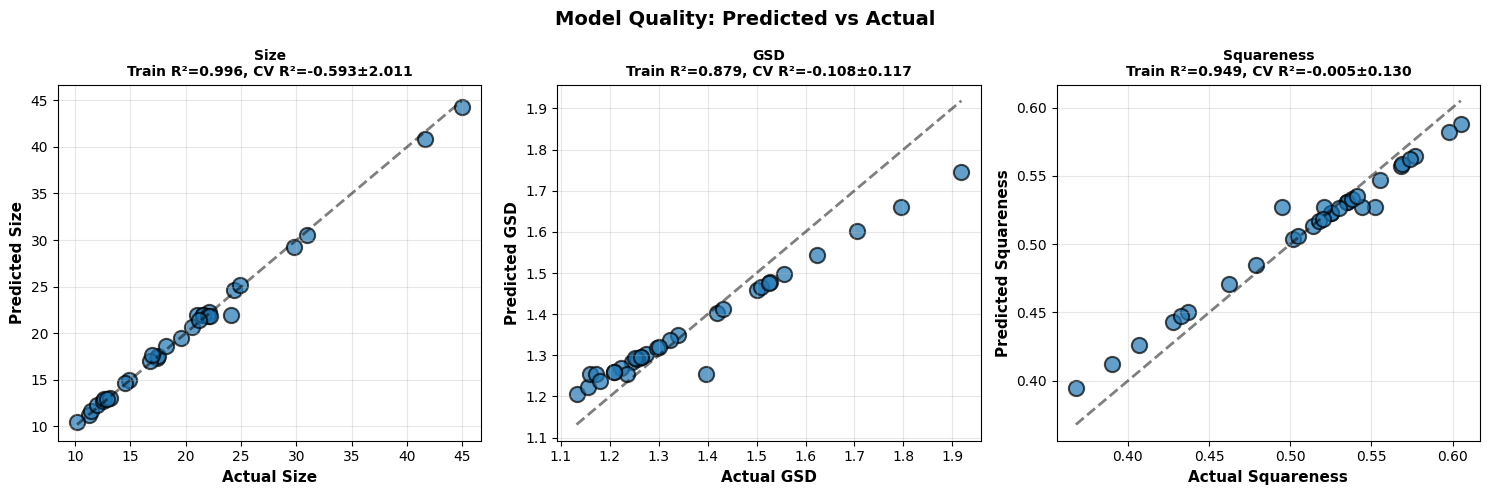

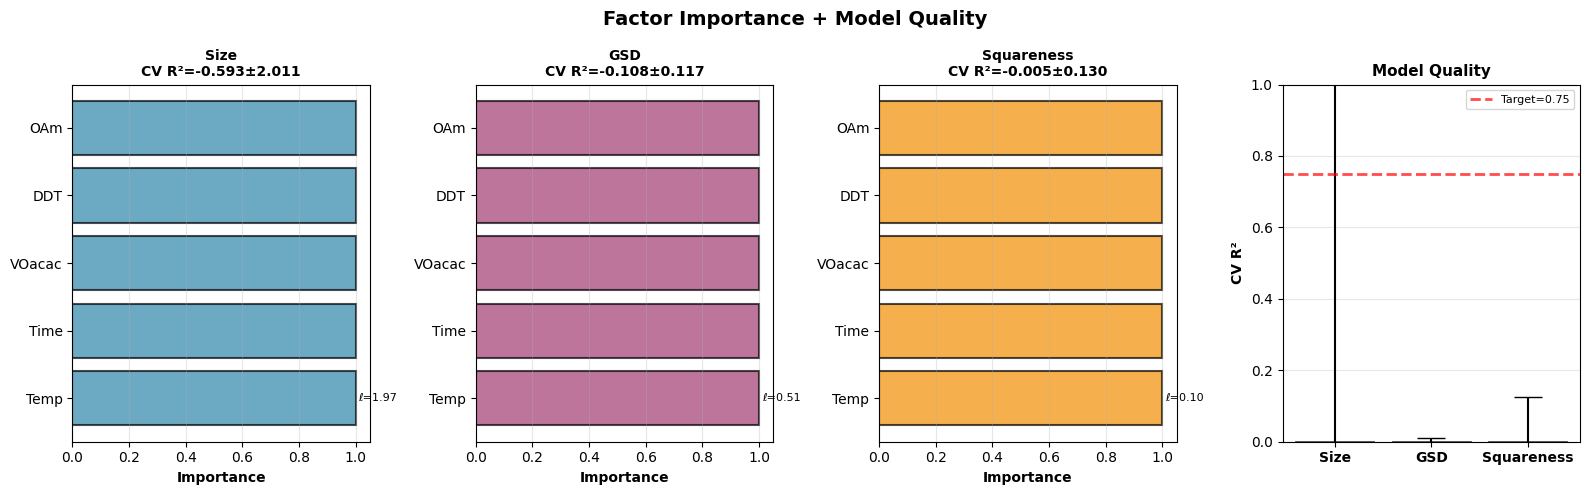

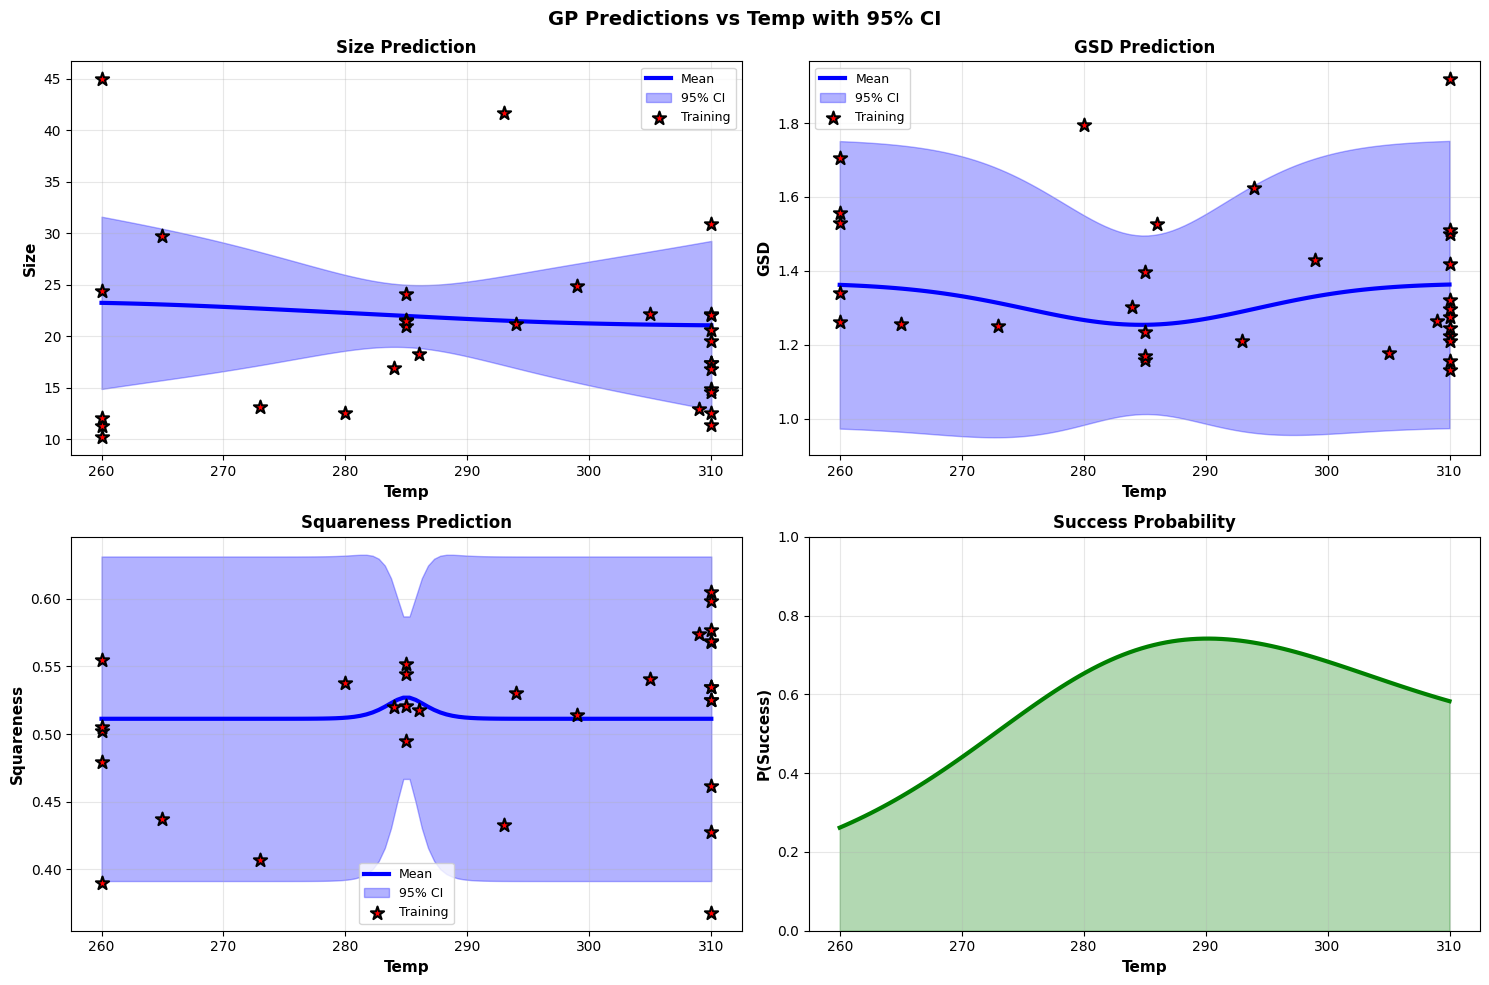

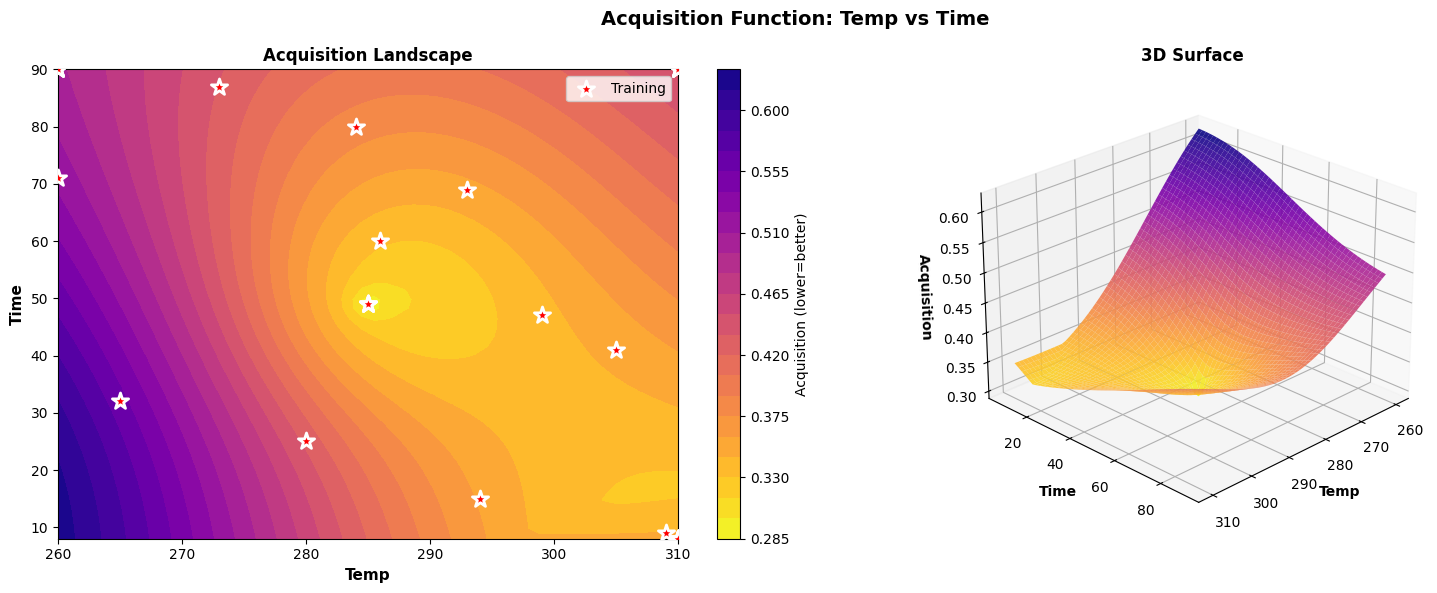

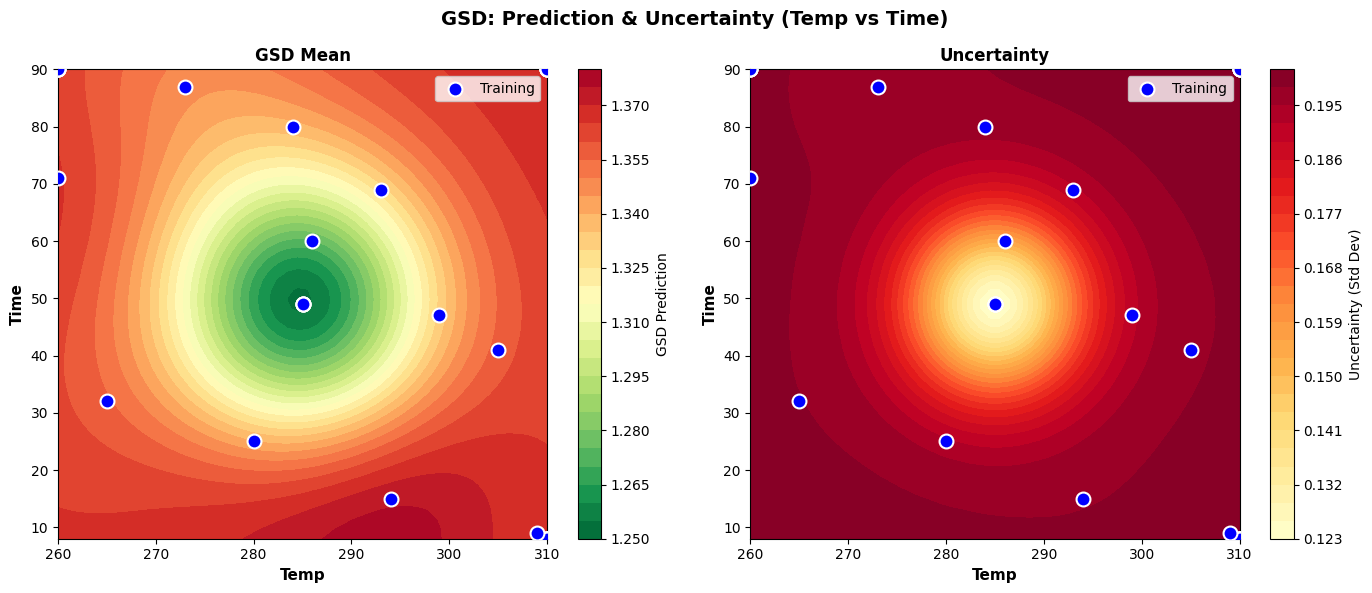

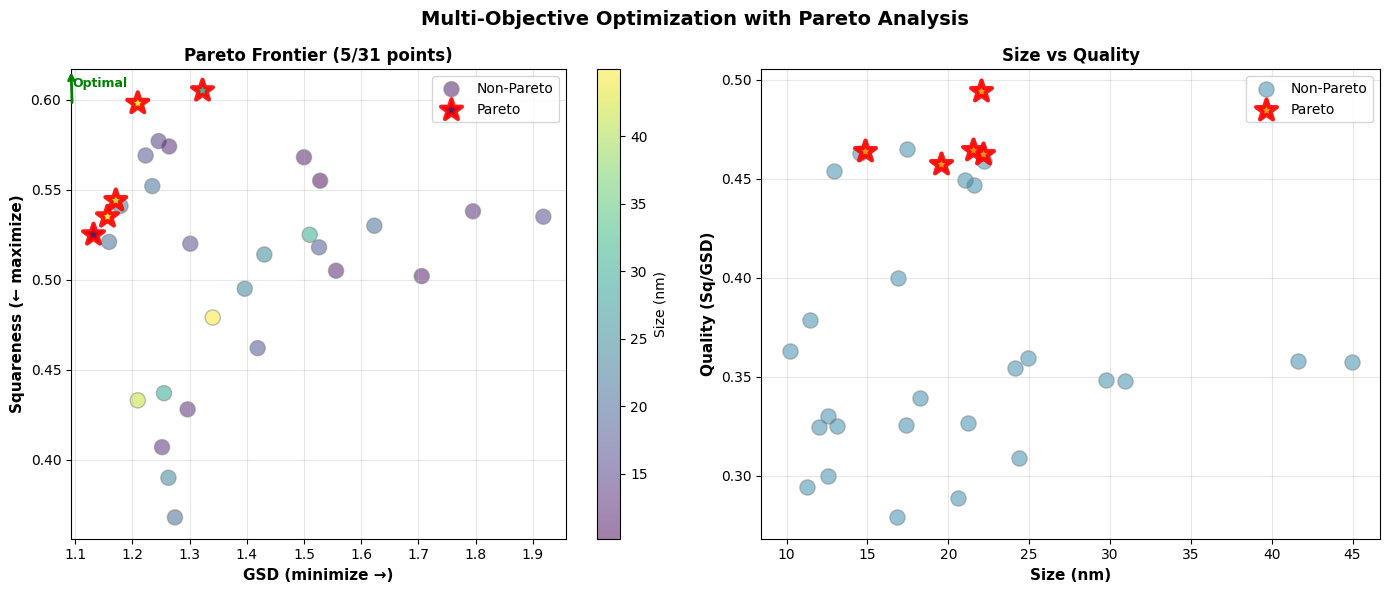

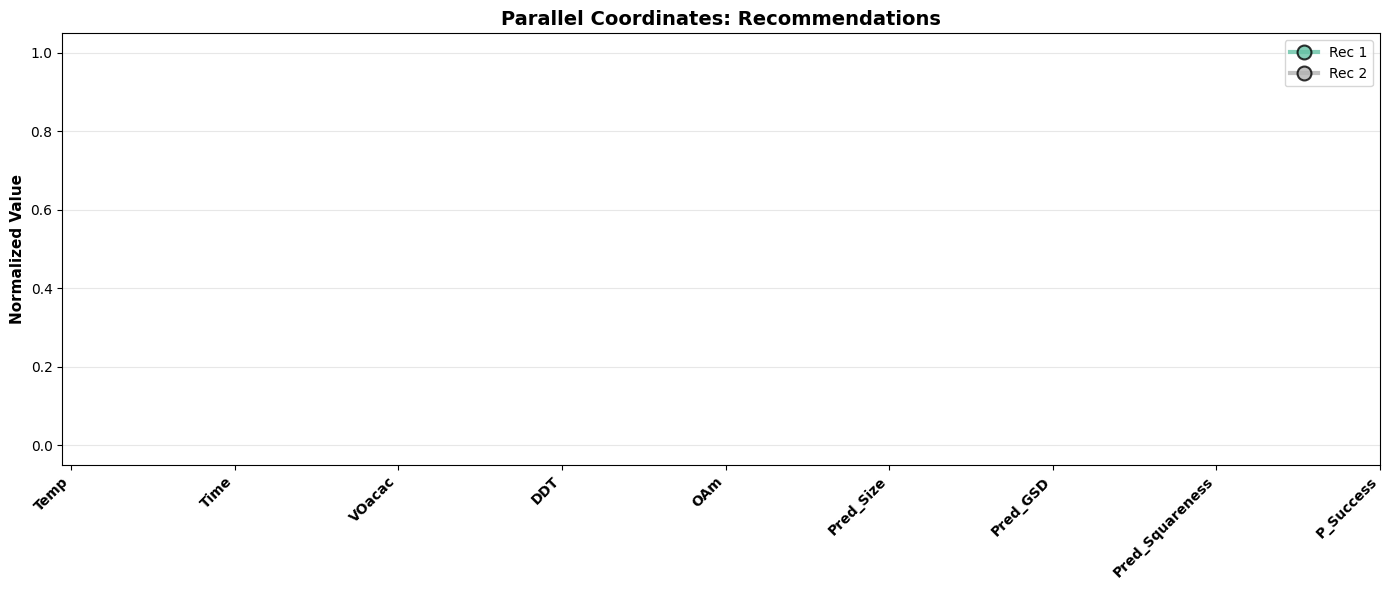

In [ ]:
from pathlib import Path
import pandas as pd
if __name__ == "__main__":

    # ========== EDIT THESE PARAMETERS ==========
    DATA_FILE = Path(r"/Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Data/COMPLETE_CUVS_DATA_SIDE2.csv")
    TARGET_SIZE = 17  # nm
    TARGET_POLYMORPH = 'cubic'
    N_RECOMMENDATIONS = 2
    ACQUISITION = 'weighted_ucb_lcb' # 'weighted_ucb_lcb'   or 'expected_improvement'
    SHOW_PLOTS = True  # Set to False to skip visualizations

    # Optional: Adjust importance weights
    """IMPORTANCE_WEIGHTS = {
        'quality': 2.0,      # Higher = prioritize GSD + Squareness more
        'size': 1.0,         # Higher = prioritize hitting target size
        'success': 1.0,      # Higher = prioritize success rate
        'polymorph': 1.0     # Higher = prioritize target polymorph
    }"""
    IMPORTANCE_WEIGHTS = None
    # ============================================

    # Run optimization
    recommendations, optimizer = run_optimization(
        df_path=DATA_FILE,
        target_size=TARGET_SIZE,
        target_polymorph=TARGET_POLYMORPH,
        importance_weights=IMPORTANCE_WEIGHTS,
        n_recommendations=N_RECOMMENDATIONS,
        acquisition=ACQUISITION
    )

    # Define the directory and create it if it doesn't exist
    output_dir = Path(r"/Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Recommendations")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Define the full file path
    output_file = output_dir / 'BO_recommendations.csv'

    # Save recommendations
    recommendations.to_csv(output_file, index=False)
    print(f"\n✓ Recommendations saved to '{output_file}'")

    # Visualizations
    if SHOW_PLOTS:
        print("\n" + "="*70)
        print("GENERATING VISUALIZATIONS")
        print("="*70)

        viz = BOVisualizer(optimizer)
        viz.plot_all(recommendations)

        # Optional: Track convergence (if you have multiple iterations)
        # tracker = OptimizationTracker()
        # tracker.log_iteration(1, df, optimizer, recommendations, TARGET_SIZE, "Initial run")
        # tracker.plot_convergence()